In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Chemins vers les données traitées
PROCESSED_PATH = '../data/processed/'
X = np.load(os.path.join(PROCESSED_PATH, 'X_train_sample.npy'))
Y = np.load(os.path.join(PROCESSED_PATH, 'Y_train_sample.npy'))

print(f"Données chargées : {X.shape[0]} patches de {X.shape[1]}x{X.shape[2]} pixels.")

Données chargées : 11 patches de 256x256 pixels.


In [24]:
def dice_loss(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1. - (2. * intersection + 1.) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1.)

In [25]:
def unet_model(input_size=(256, 256, 3)):
    inputs = Input(input_size)

    # ENCODEUR (Contraction)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = layers.Dropout(0.1)(c1)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = layers.Dropout(0.1)(c2)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # BOTTLENECK
    c3 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = layers.Dropout(0.2)(c3)
    c3 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)

    # DÉCODEUR (Expansion)
    u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u4)
    c4 = layers.Dropout(0.1)(c4)
    c4 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)

    u5 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u5)
    c5 = layers.Dropout(0.1)(c5)
    c5 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    # SORTIE
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# Initialisation et compilation avec Dice Loss
model = unet_model()
model.compile(optimizer='adam', loss=dice_loss, metrics=['accuracy'])

In [26]:
# On augmente à 50 époques pour garantir que l'IA "ose" prédire du blanc
print("Début de l'entraînement...")
history = model.fit(
    X, Y,
    epochs=50,
    batch_size=2,
    shuffle=True,
    verbose=1
)
print("Entraînement terminé !")

Début de l'entraînement...
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.4539 - loss: 0.8911
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.2632 - loss: 0.8675
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.4698 - loss: 0.8584
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.8825 - loss: 0.9046
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.9325 - loss: 0.9045
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9144 - loss: 0.8911
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.8910 - loss: 0.8909
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.7208 - loss: 0.8758
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.7313 - loss: 0.8543
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.7974 - loss: 0.8048
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.9470 - loss: 0.5452
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/s

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


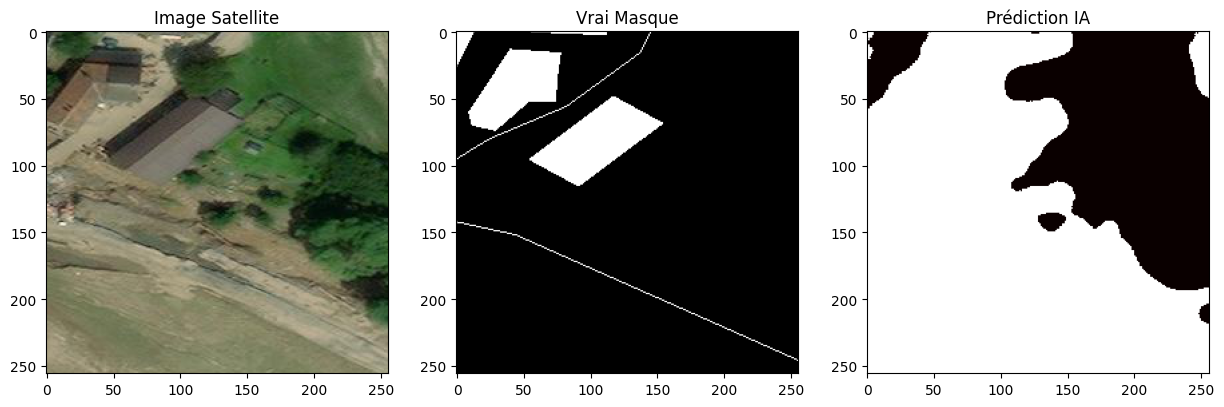

Modèle sauvegardé avec succès dans /models/ !


In [28]:
# 1. Prédiction sur un patch riche
idx = 8 # Patch avec bâtiment et route
preds = model.predict(X[idx:idx+1])
preds_t = (preds > 0.5).astype(np.uint8)

# 2. Affichage
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(X[idx]); plt.title("Image Satellite")
plt.subplot(1, 3, 2); plt.imshow(Y[idx], cmap='gray'); plt.title("Vrai Masque")
plt.subplot(1, 3, 3); plt.imshow(preds_t[0].squeeze(), cmap='hot'); plt.title("Prédiction IA")
plt.show()

# 3. Sauvegarde du modèle
if not os.path.exists('../models/'):
    os.makedirs('../models/')
model.save('../models/unet_spacenet_v1.keras')
print("Modèle sauvegardé avec succès dans /models/ !")